In [4]:
import numpy as np
import matplotlib.pyplot as plt
import Optimal_transport as OT
from scipy.optimize import minimize


def Gradient(x0,f,h=1e-2):
    
    '''
    Approximate the Gradient vector of f at x0 using finite differences, knowing the value of f at every point of the domain

    x0: n-vecteur containing the parameter value at which the hessian should be evaluated

    f: Function that return a value for a list of parameter x


    '''

    dim=f.__code__.co_argcount
    Gradient=np.zeros((dim))    
    for i in range(dim):
            Gradient[i]= (f(*(x0+np.array([h/2 if k == i else 0 for k in range(dim)])))
                        -f(*(x0-np.array([h/2 if k == i else 0 for k in range(dim)]))))/h
      
    return Gradient


def steepest_descent(X0,f,num_iter_max=100,eps=1e-3,Xmin=[0,0],Xmax=[1,1],eta=1e-3,h=1e-2):
    """
    Compute the steepest descent algorithm
    
    Parameters
    ----------
    
    X0: array, starting position
    f: function to be minimised 
    num_iter_max: int, maximum number of iteration
    eps: float, precision for the final result
    Xmin: array, minimum bounds
    Xmax: array, maximum bounds
    eta: float, learning rate
    h: float, gradient evaluation precision
    
    
    Returns
    -------
    
    X: Final position
    Err: list of all errors from X0 to X
    Xs: list of all positions from X0 to X
    
    """
    
    dim=f.__code__.co_argcount

    X=X0
    Xs=[X0]
    Err=[]
    for i in range(num_iter_max):
        
        if all(list(map(lambda x,y,z : x>=y and x<=z, X,Xmin,Xmax))):
            Err.append(f(*X))
            
            dk=-1*eta*Gradient(X,f,h)
            if np.sum(abs(dk))<=eps:
                print('Descent finished')
                break
            X=X+dk
            Xs.append(X)
        else:
            Err.append(f(*X))
            print('X got out of bound')
            break
        if i==num_iter_max-1:
            print('Maximum number of iteration reached')
    return np.array(X),np.array(Err),np.array(Xs)

    
    
# Analytical solution of Welty (1994)

def diverging(t,alpha,R,Q,Phi,L,M=1,rho=1000):
        
    """
    Compute the Concentration of a tracer in a well in diverging radial flow a single injection according to Welty 1994
    
    Parameters
    ----------
    
    t: float, time at which the concentration is observed
    alpha: float, Longitudinal dispersivity (m)
    R: float, distance tracer imput to the well (m)
    Q: float, Discharge of the well (m3/s)
    Phi: float, Porosity (no units)
    L: float, Width of the aquifer(m)
    M: Mass of injected tracer (kg)
    rho: volumetric mass of water (kg/m3)
    
    Returns
    -------
    
    float, concentration in the well at t
    
    """
    
    tc=t/(R**2 *np.pi*Phi*L/Q)
    e=-1*(1-tc)**2/((16*alpha*tc**1.5)/(3*R))
    denom=np.sqrt(tc**1.5)
    c_norm=np.nan_to_num(np.exp(e)/denom)
    return c_norm*M/(rho*2*np.pi*Phi*L*(R**2)*np.sqrt(4*np.pi*alpha/(3*R)))


def multipeaks(times,t_start,alpha,R,Q,Phi,L,M=1,rho=1000): 
    """
    Compute the Concentration of a tracer in a well in diverging radial flow with multiple injections according to Welty 1994
    
    Parameters
    ----------
    
    times: List or numpy Array, contains the time steps
    t_start: List or numpy Array, contains the starting times of all the injections
    alpha: float, Longitudinal dispersivity (m)
    R: float, distance tracer imput to the well (m)
    Q: float, Discharge of the well (m3/s)
    Phi: float, Porosity (no units)
    L: float, Width of the aquifer(m)
    M: Mass of injected tracer (kg)
    rho: volumetric mass of water (kg/m3)
    
    Returns
    -------
    
    List or numpy Array, contains the concentration in the well for every time steps of t
    
    """
    
    res=np.zeros(len(times))
    for k in range(len(t_start)):
        t=times-t_start[k]
        res[t>0]+=diverging(t[t>0],alpha,R,Q,Phi,L,M=M,rho=rho)
    return res



def recuit_simule_hybride(fonction, bornes, cs_noise, n_iterations=2000, temp_initiale=1, alpha=0.98, taille_pas=0.05):
    """
    Find the global minimum of a fonction based on a simulated annealing algorithm followed by a gradient descent
    
    Parameters
    ----------
    
    fonction: function, the one we want to optimize
    bornes: List or numpy Array, contains the borns that can not be exceeded
    cs_noise: List, Concentration data time series 
    n_iterations: int, number of iterations
    temp_iniatiale: float, initial temperature of the simulated annealing algorithm
    alpha: float, control the decreasing rate of the temperature of the simulated annealing algorithm
    taille_pas: float, step size in the parameter domain
    
    Returns
    -------
    
    x: Position of the best parameters
    fun: Minimum value of the function
    historique: History of all parameters tried
    
    """
    
    b_min, b_max = np.array(bornes)[:, 0], np.array(bornes)[:, 1]
    
    etat_actuel = b_min + np.random.rand(2) * (b_max - b_min)
    score_actuel = fonction(etat_actuel, cs_noise) 
    
    meilleur_etat = etat_actuel.copy()
    meilleur_score = score_actuel
    
    t = temp_initiale
    historique = [etat_actuel.copy()]
    
    for i in range(n_iterations):
        bruit = np.random.normal(0, taille_pas, size=2)
        candidat = np.clip(etat_actuel + bruit, b_min, b_max)
        score_candidat = fonction(candidat, cs_noise) 
        meilleur_score = score_candidat
        meilleur_estado = candidat.copy()        
        diff = score_candidat - score_actuel
        if diff < 0 or np.random.rand() < np.exp(-diff / t):
            etat_actuel, score_actuel = candidat, score_candidat
            historique.append(etat_actuel.copy())
            if score_candidat < meilleur_score:
                meilleur_score = score_candidat
                meilleur_estado = candidat.copy()
                
        t = t * alpha

    res = minimize(
        fonction, 
        x0=meilleur_estado, 
        bounds=bornes, 
        args=(cs_noise,), # <-- Indispensable pour Nelder-Mead
        method='Nelder-Mead',
        options={'xatol': 1e-6, 'fatol': 1e-6} 
    )
    
    historique.append(res.x)
    return res.x, res.fun, np.array(historique)



def add_noise(ts,std_dev,mean=0):

    noise = np.random.normal(mean, std_dev, ts.shape)
    noisy_ts = ts + noise

    return np.clip(noisy_ts,0,None)

def f_L2(x,cs_noise):
    """
    Objective fonction using L2 distances
    
    Parameters
    ----------
    
    alpha_n: float between 0 and 1, normalised dispersivity
    phi_n: float between 0 and 1, normalised porosity
    cs_noise: List, Concentration data time series 
    
    Returns
    -------
    
    float, L2 error
    
    """
    alpha_n,phi_n=x
    alpha=10**(alpha_n*2-1)
    phi=10**(phi_n-1.3)
    cs=multipeaks(times,[0,20*seconds_in_day],alpha=alpha,R=220,Q=10000/1000/60,Phi=phi,L=20)
    
    return np.sum(((cs-cs_noise)/np.max(cs_noise))**2) 


def f_WD(x,cs_noise):

    """
    Objective fonction using Wasserstein distances
    
    Parameters
    ----------
    
    alpha_n: float between 0 and 1, normalised dispersivity
    phi_n: float between 0 and 1, normalised porosity
    cs_noise: List, Concentration data time series 
    
    Returns
    -------
    
    float, Wasserstein distance error
    
    """
    alpha_n,phi_n=x
    alpha=10**(alpha_n*2-1)
    phi=10**(phi_n-1.3)
    
    cs=multipeaks(times,[0,20*seconds_in_day],alpha=alpha,R=220,Q=10000/1000/60,Phi=phi,L=20)
    
    return OT.optimal_transport(times,cs_noise,times,cs,reg=1)/np.max(cs_noise) 

def f_Sinkhorn(x,cs_noise):
    """
    Objective fonction using Sinkhorn distances
    
    Parameters
    ----------
    
    alpha_n: float between 0 and 1, normalised dispersivity
    phi_n: float between 0 and 1, normalised porosity
    cs_noise: List, Concentration data time series 
    
    Returns
    -------
    
    float, Sinkhorn error
    
    """
    alpha_n,phi_n=x
    alpha=10**(alpha_n*2-1)
    phi=10**(phi_n-1.3)
    
    cs=multipeaks(times,[0,20*seconds_in_day],alpha=alpha,R=220,Q=10000/1000/60,Phi=phi,L=20)
    
    return OT.optimal_transport(times,cs_noise,times,cs,Sinkhorn_dist=True,reg=1,logeps=3,NumIterMax=200,k1=.2,k2=1)/np.max(cs_target)


alpha_target=1
phi_target=0.15

seconds_in_day=3600*24
times=np.linspace(100,seconds_in_day*100,200)
cs_target=multipeaks(times,[0,20*seconds_in_day],alpha=alpha_target,R=220,Q=10000/1000/60,Phi=phi_target,L=20)



# Small model error

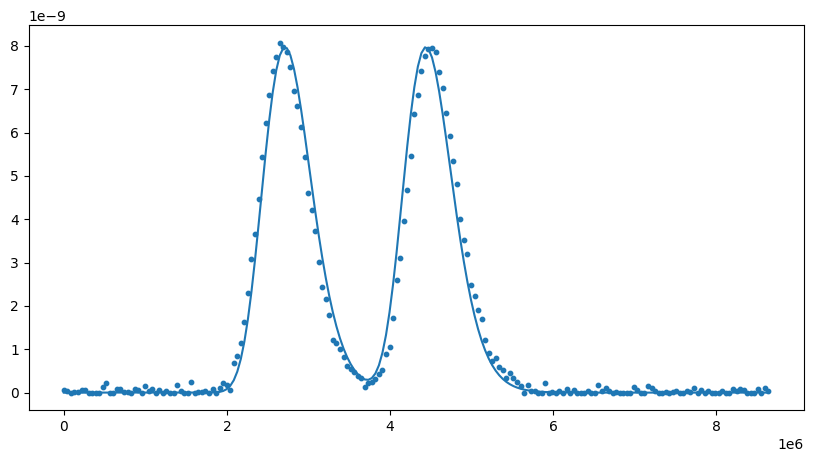

In [5]:
ndays=1
std_dev=.2e-9
np.random.seed(10044343)
random_time_shift1=(np.random.random()-0.5)*seconds_in_day*ndays*2
random_time_shift2=(np.random.random()-0.5)*seconds_in_day*ndays*2


cs_noise=add_noise(multipeaks(times,[0+random_time_shift1,20*seconds_in_day+random_time_shift2],alpha=alpha_target,
                              R=220,Q=10000/1000/60,Phi=phi_target,L=20),
                              std_dev=.1e-9)


plt.figure(figsize=(10,5))
plt.plot(times,cs_target)
plt.scatter(times,cs_noise,s=10)

In [6]:
x = np.linspace(0, 1, 50)
y = np.linspace(0, 1, 50)
X, Y = np.meshgrid(x, y)
Z_L2 = np.zeros((50,50))
Z_WD = np.zeros((50,50))
Z_Sinkhorn = np.zeros((50,50))
for i in range(50):
    for j in range(50):
        Z_L2[i,j]=f_L2([X[i,j],Y[i,j]],cs_noise)
        Z_WD[i,j]=f_WD([X[i,j],Y[i,j]],cs_noise)
        Z_Sinkhorn[i,j]=f_Sinkhorn([X[i,j],Y[i,j]],cs_noise)


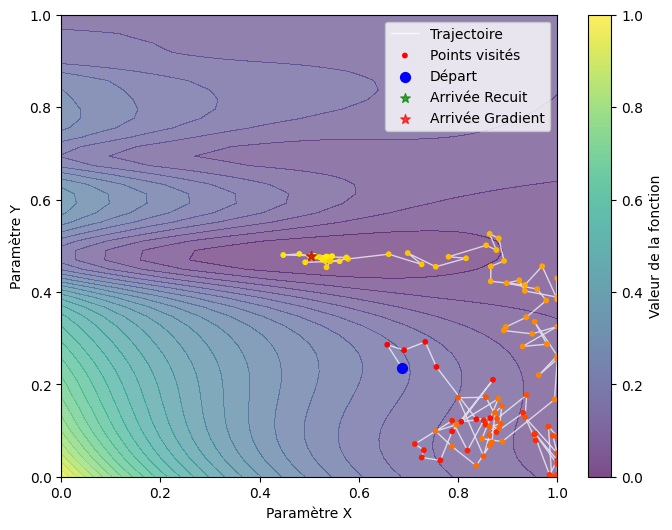

In [7]:
meilleure_position_L2, meilleur_score_final,parcours = recuit_simule_hybride(f_L2, [[0,1],[0,1]],cs_noise,temp_initiale=10,taille_pas=0.05)

plt.figure(figsize=(8, 6))


plt.contourf(X, Y, Z_L2, levels=30, cmap='viridis', alpha=0.6)
plt.plot(parcours[:, 0], parcours[:, 1], color='white', linestyle='-', linewidth=1, alpha=0.7, label='Trajectoire')
plt.scatter(parcours[:, 0], parcours[:, 1], c=range(len(parcours)), cmap='autumn', s=10, zorder=3, label='Points visités')

plt.scatter(parcours[0, 0], parcours[0, 1], color='blue', s=50, marker='o', zorder=5, label='Départ')
plt.scatter(parcours[-2, 0], parcours[-2, 1], color='green', s=50, marker='*', zorder=5, label='Arrivée Recuit',alpha=.7)
plt.scatter(parcours[-1, 0], parcours[-1, 1], color='red', s=50, marker='*', zorder=5, label='Arrivée Gradient',alpha=.7)
plt.colorbar(label='Valeur de la fonction')
plt.legend()
plt.xlabel("Paramètre X")
plt.ylabel("Paramètre Y")
plt.show()

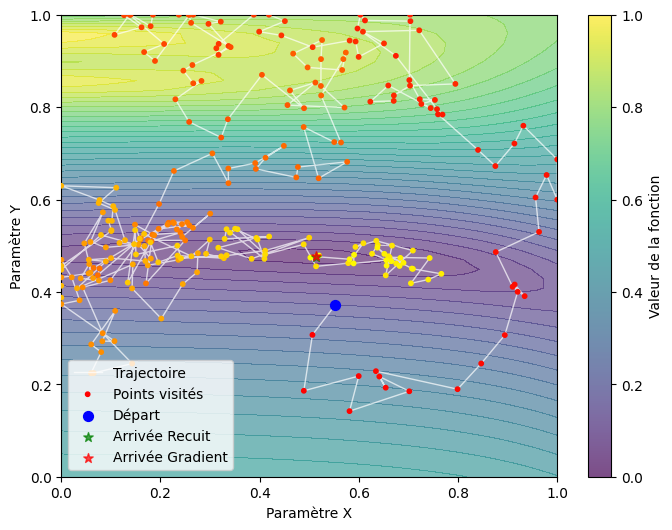

In [8]:
meilleure_position_WD, meilleur_score_final,parcours = recuit_simule_hybride(f_WD, [[0,1],[0,1]],cs_noise,temp_initiale=.5,taille_pas=0.05)

plt.figure(figsize=(8, 6))

plt.contourf(X, Y, Z_WD, levels=30, cmap='viridis', alpha=0.6)

plt.plot(parcours[:, 0], parcours[:, 1], color='white', linestyle='-', linewidth=1, alpha=0.7, label='Trajectoire')
plt.scatter(parcours[:, 0], parcours[:, 1], c=range(len(parcours)), cmap='autumn', s=10, zorder=3, label='Points visités')


plt.scatter(parcours[0, 0], parcours[0, 1], color='blue', s=50, marker='o', zorder=5, label='Départ')
plt.scatter(parcours[-2, 0], parcours[-2, 1], color='green', s=50, marker='*', zorder=5, label='Arrivée Recuit',alpha=.7)
plt.scatter(parcours[-1, 0], parcours[-1, 1], color='red', s=50, marker='*', zorder=5, label='Arrivée Gradient',alpha=.7)
plt.colorbar(label='Valeur de la fonction')

plt.xlabel("Paramètre X")
plt.ylabel("Paramètre Y")
plt.legend()
plt.show()

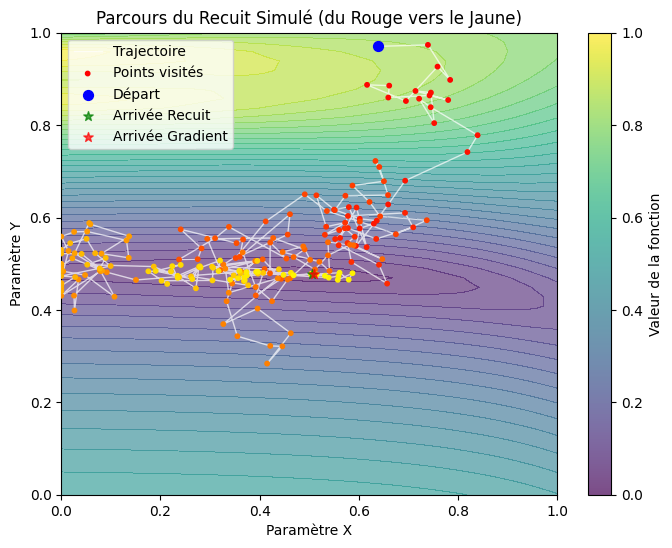

In [9]:
meilleure_position_Sinkhorn, meilleur_score_final,parcours = recuit_simule_hybride(f_Sinkhorn, [[0,1],[0,1]],cs_noise,temp_initiale=1)

plt.figure(figsize=(8, 6))

plt.contourf(X, Y, Z_WD, levels=30, cmap='viridis', alpha=0.6)
plt.plot(parcours[:, 0], parcours[:, 1], color='white', linestyle='-', linewidth=1, alpha=0.7, label='Trajectoire')
plt.scatter(parcours[:, 0], parcours[:, 1], c=range(len(parcours)), cmap='autumn', s=10, zorder=3, label='Points visités')

plt.scatter(parcours[0, 0], parcours[0, 1], color='blue', s=50, marker='o', zorder=5, label='Départ')
plt.scatter(parcours[-2, 0], parcours[-2, 1], color='green', s=50, marker='*', zorder=5, label='Arrivée Recuit',alpha=.7)
plt.scatter(parcours[-1, 0], parcours[-1, 1], color='red', s=50, marker='*', zorder=5, label='Arrivée Gradient',alpha=.7)
plt.colorbar(label='Valeur de la fonction')
plt.title("Parcours du Recuit Simulé (du Rouge vers le Jaune)")
plt.xlabel("Paramètre X")
plt.ylabel("Paramètre Y")
plt.legend()
plt.show()

In [10]:
alpha_n,phi_n=meilleure_position_L2
alpha=10**(alpha_n*2-1)
phi=10**(phi_n-1.3)

cs_noise_small=cs_noise.copy()
cs_L2_small=multipeaks(times,[0,20*seconds_in_day],alpha=alpha,R=220,Q=10000/1000/60,Phi=phi,L=20)

alpha_n,phi_n=meilleure_position_WD
alpha=10**(alpha_n*2-1)
phi=10**(phi_n-1.3)
    
cs_WD_small=multipeaks(times,[0,20*seconds_in_day],alpha=alpha,R=220,Q=10000/1000/60,Phi=phi,L=20)

alpha_n,phi_n=meilleure_position_Sinkhorn
alpha=10**(alpha_n*2-1)
phi=10**(phi_n-1.3)
    
cs_Sinkhorn_small=multipeaks(times,[0,20*seconds_in_day],alpha=alpha,R=220,Q=10000/1000/60,Phi=phi,L=20)

# Large model error

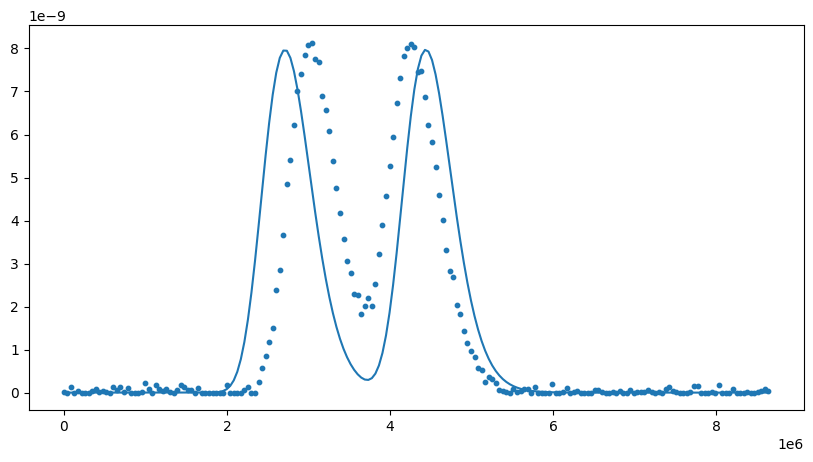

In [11]:
ndays=4
std_dev=.2e-9
np.random.seed(465293)
random_time_shift1=(np.random.random()-0.5)*seconds_in_day*ndays*2
random_time_shift2=(np.random.random()-0.5)*seconds_in_day*ndays*2


cs_noise=add_noise(multipeaks(times,[0+random_time_shift1,20*seconds_in_day+random_time_shift2],alpha=alpha_target,
                              R=220,Q=10000/1000/60,Phi=phi_target,L=20),
                              std_dev=.1e-9)


plt.figure(figsize=(10,5))
plt.plot(times,cs_target)
plt.scatter(times,cs_noise,s=10)

In [12]:
x = np.linspace(0, 1, 50)
y = np.linspace(0, 1, 50)
X, Y = np.meshgrid(x, y)
Z_L2 = np.zeros((50,50))
Z_WD = np.zeros((50,50))
Z_Sinkhorn = np.zeros((50,50))
for i in range(50):
    for j in range(50):
        Z_L2[i,j]=f_L2([X[i,j],Y[i,j]],cs_noise)
        Z_WD[i,j]=f_WD([X[i,j],Y[i,j]],cs_noise)
        Z_Sinkhorn[i,j]=f_Sinkhorn([X[i,j],Y[i,j]],cs_noise)


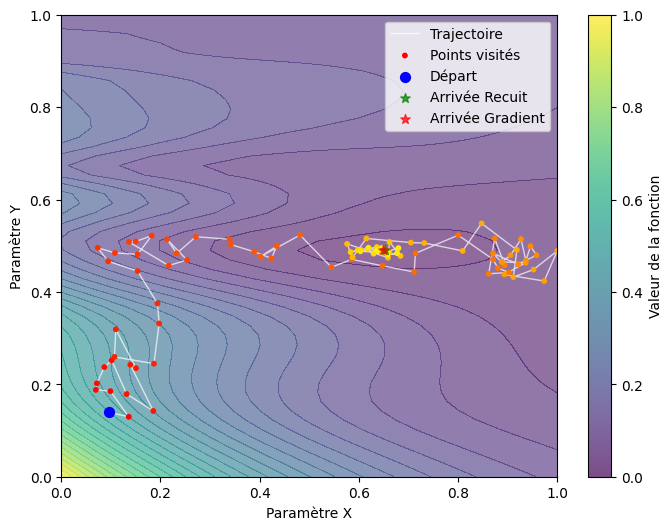

In [13]:
meilleure_position_L2, meilleur_score_final,parcours = recuit_simule_hybride(f_L2, [[0,1],[0,1]],cs_noise,temp_initiale=10)

plt.figure(figsize=(8, 6))


plt.contourf(X, Y, Z_L2, levels=30, cmap='viridis', alpha=0.6)
plt.plot(parcours[:, 0], parcours[:, 1], color='white', linestyle='-', linewidth=1, alpha=0.7, label='Trajectoire')
plt.scatter(parcours[:, 0], parcours[:, 1], c=range(len(parcours)), cmap='autumn', s=10, zorder=3, label='Points visités')

plt.scatter(parcours[0, 0], parcours[0, 1], color='blue', s=50, marker='o', zorder=5, label='Départ')
plt.scatter(parcours[-2, 0], parcours[-2, 1], color='green', s=50, marker='*', zorder=5, label='Arrivée Recuit',alpha=.7)
plt.scatter(parcours[-1, 0], parcours[-1, 1], color='red', s=50, marker='*', zorder=5, label='Arrivée Gradient',alpha=.7)
plt.colorbar(label='Valeur de la fonction')
plt.legend()
plt.xlabel("Paramètre X")
plt.ylabel("Paramètre Y")
plt.show()

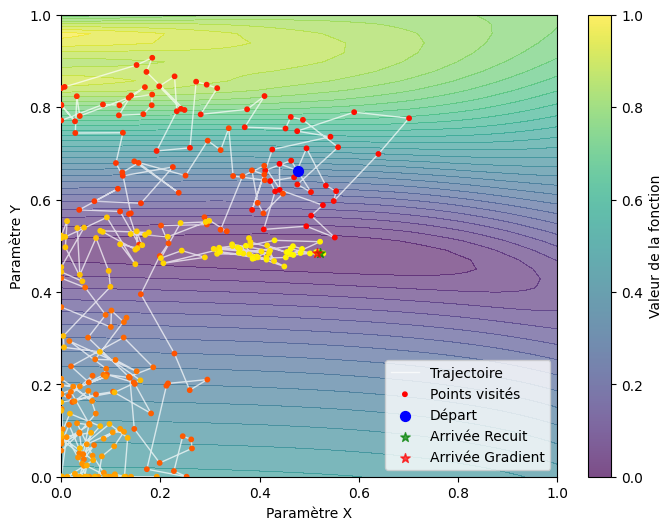

In [14]:
meilleure_position_WD, meilleur_score_final,parcours = recuit_simule_hybride(f_WD, [[0,1],[0,1]],cs_noise,temp_initiale=.5)

plt.figure(figsize=(8, 6))

plt.contourf(X, Y, Z_WD, levels=30, cmap='viridis', alpha=0.6)

plt.plot(parcours[:, 0], parcours[:, 1], color='white', linestyle='-', linewidth=1, alpha=0.7, label='Trajectoire')
plt.scatter(parcours[:, 0], parcours[:, 1], c=range(len(parcours)), cmap='autumn', s=10, zorder=3, label='Points visités')

plt.scatter(parcours[0, 0], parcours[0, 1], color='blue', s=50, marker='o', zorder=5, label='Départ')
plt.scatter(parcours[-2, 0], parcours[-2, 1], color='green', s=50, marker='*', zorder=5, label='Arrivée Recuit',alpha=.7)
plt.scatter(parcours[-1, 0], parcours[-1, 1], color='red', s=50, marker='*', zorder=5, label='Arrivée Gradient',alpha=.7)
plt.colorbar(label='Valeur de la fonction')

plt.xlabel("Paramètre X")
plt.ylabel("Paramètre Y")
plt.legend()
plt.show()

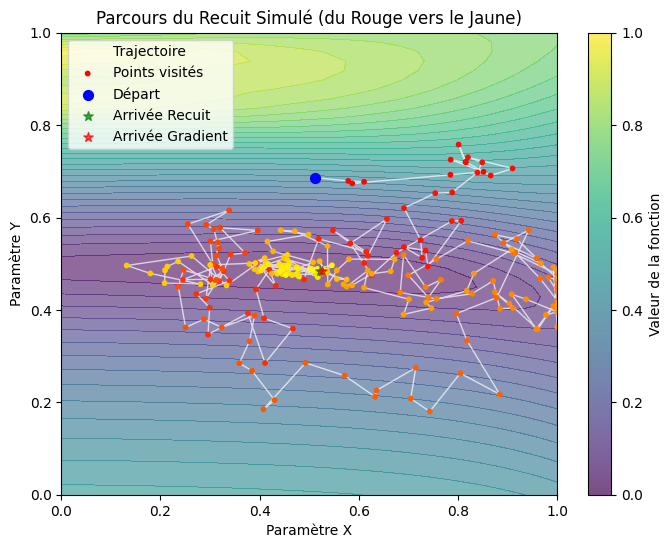

In [15]:
meilleure_position_Sinkhorn, meilleur_score_final,parcours = recuit_simule_hybride(f_Sinkhorn, [[0,1],[0,1]],cs_noise,temp_initiale=1)

plt.figure(figsize=(8, 6))

plt.contourf(X, Y, Z_WD, levels=30, cmap='viridis', alpha=0.6)
plt.plot(parcours[:, 0], parcours[:, 1], color='white', linestyle='-', linewidth=1, alpha=0.7, label='Trajectoire')
plt.scatter(parcours[:, 0], parcours[:, 1], c=range(len(parcours)), cmap='autumn', s=10, zorder=3, label='Points visités')

plt.scatter(parcours[0, 0], parcours[0, 1], color='blue', s=50, marker='o', zorder=5, label='Départ')
plt.scatter(parcours[-2, 0], parcours[-2, 1], color='green', s=50, marker='*', zorder=5, label='Arrivée Recuit',alpha=.7)
plt.scatter(parcours[-1, 0], parcours[-1, 1], color='red', s=50, marker='*', zorder=5, label='Arrivée Gradient',alpha=.7)
plt.colorbar(label='Valeur de la fonction')
plt.title("Parcours du Recuit Simulé (du Rouge vers le Jaune)")
plt.xlabel("Paramètre X")
plt.ylabel("Paramètre Y")
plt.legend()
plt.show()

In [16]:
alpha_n,phi_n=meilleure_position_L2
alpha=10**(alpha_n*2-1)
phi=10**(phi_n-1.3)
cs_noise_large=cs_noise.copy()
cs_L2_large=multipeaks(times,[0,20*seconds_in_day],alpha=alpha,R=220,Q=10000/1000/60,Phi=phi,L=20)

alpha_n,phi_n=meilleure_position_WD
alpha=10**(alpha_n*2-1)
phi=10**(phi_n-1.3)
    
cs_WD_large=multipeaks(times,[0,20*seconds_in_day],alpha=alpha,R=220,Q=10000/1000/60,Phi=phi,L=20)

alpha_n,phi_n=meilleure_position_Sinkhorn
alpha=10**(alpha_n*2-1)
phi=10**(phi_n-1.3)
    
cs_Sinkhorn_large=multipeaks(times,[0,20*seconds_in_day],alpha=alpha,R=220,Q=10000/1000/60,Phi=phi,L=20)

# Undersampling

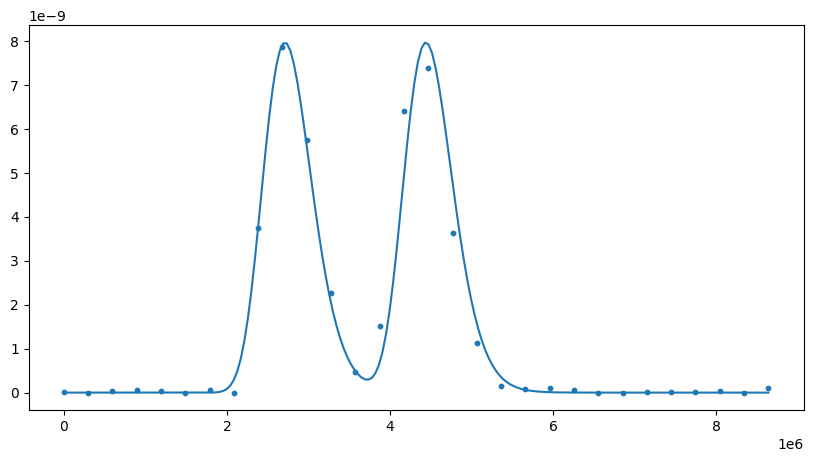

In [17]:
times_norm=np.linspace(100,seconds_in_day*100,200)
times=np.linspace(100,seconds_in_day*100,30)
ndays=1
std_dev=.2e-9
np.random.seed(258733)
random_time_shift1=(np.random.random()-0.5)*seconds_in_day*ndays*2
random_time_shift2=(np.random.random()-0.5)*seconds_in_day*ndays*2


cs_noise=add_noise(multipeaks(times,[0+random_time_shift1,20*seconds_in_day+random_time_shift2],alpha=alpha_target,
                              R=220,Q=10000/1000/60,Phi=phi_target,L=20),
                              std_dev=.1e-9)


plt.figure(figsize=(10,5))
plt.plot(times_norm,cs_target)
plt.scatter(times,cs_noise,s=10)

In [18]:
x = np.linspace(0, 1, 50)
y = np.linspace(0, 1, 50)
X, Y = np.meshgrid(x, y)
Z_L2 = np.zeros((50,50))
Z_WD = np.zeros((50,50))
Z_Sinkhorn = np.zeros((50,50))
for i in range(50):
    for j in range(50):
        Z_L2[i,j]=f_L2([X[i,j],Y[i,j]],cs_noise)
        Z_WD[i,j]=f_WD([X[i,j],Y[i,j]],cs_noise)
        Z_Sinkhorn[i,j]=f_Sinkhorn([X[i,j],Y[i,j]],cs_noise)


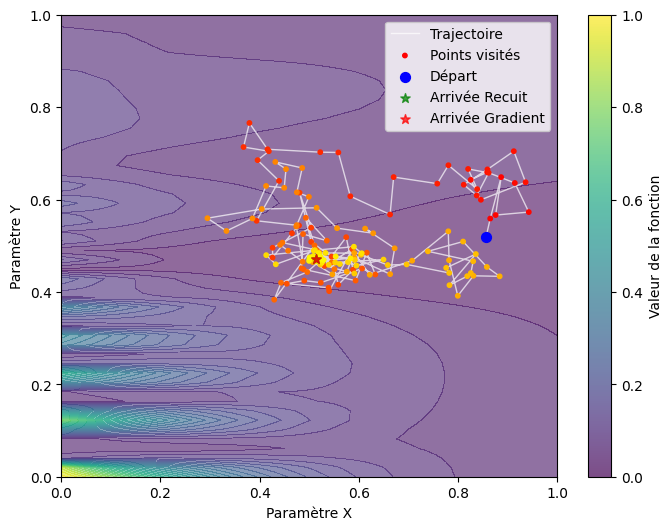

In [19]:
meilleure_position_L2, meilleur_score_final,parcours = recuit_simule_hybride(f_L2, [[0,1],[0,1]],cs_noise,temp_initiale=10)

plt.figure(figsize=(8, 6))


plt.contourf(X, Y, Z_L2, levels=30, cmap='viridis', alpha=0.6)
plt.plot(parcours[:, 0], parcours[:, 1], color='white', linestyle='-', linewidth=1, alpha=0.7, label='Trajectoire')
plt.scatter(parcours[:, 0], parcours[:, 1], c=range(len(parcours)), cmap='autumn', s=10, zorder=3, label='Points visités')

plt.scatter(parcours[0, 0], parcours[0, 1], color='blue', s=50, marker='o', zorder=5, label='Départ')
plt.scatter(parcours[-2, 0], parcours[-2, 1], color='green', s=50, marker='*', zorder=5, label='Arrivée Recuit',alpha=.7)
plt.scatter(parcours[-1, 0], parcours[-1, 1], color='red', s=50, marker='*', zorder=5, label='Arrivée Gradient',alpha=.7)
plt.colorbar(label='Valeur de la fonction')
plt.legend()
plt.xlabel("Paramètre X")
plt.ylabel("Paramètre Y")
plt.show()

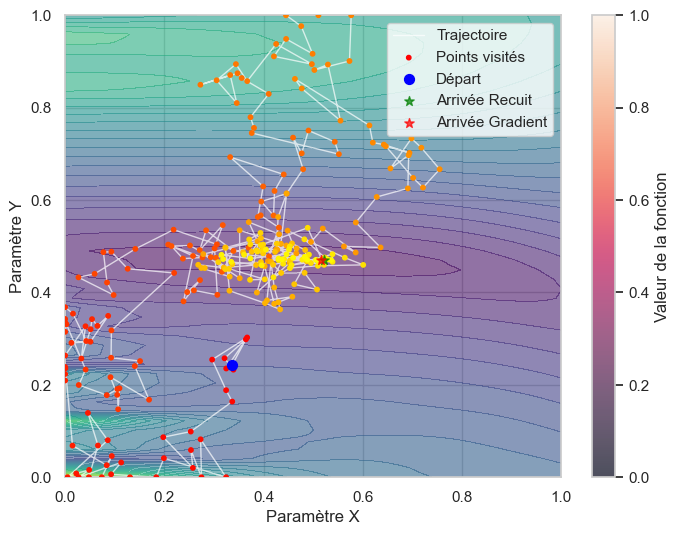

In [26]:
meilleure_position_WD, meilleur_score_final,parcours = recuit_simule_hybride(f_WD, [[0,1],[0,1]],cs_noise,temp_initiale=.5,taille_pas=0.05)

plt.figure(figsize=(8, 6))

plt.contourf(X, Y, Z_WD, levels=30, cmap='viridis', alpha=0.6)
plt.plot(parcours[:, 0], parcours[:, 1], color='white', linestyle='-', linewidth=1, alpha=0.7, label='Trajectoire')
plt.scatter(parcours[:, 0], parcours[:, 1], c=range(len(parcours)), cmap='autumn', s=10, zorder=3, label='Points visités')

plt.scatter(parcours[0, 0], parcours[0, 1], color='blue', s=50, marker='o', zorder=5, label='Départ')
plt.scatter(parcours[-2, 0], parcours[-2, 1], color='green', s=50, marker='*', zorder=5, label='Arrivée Recuit',alpha=.7)
plt.scatter(parcours[-1, 0], parcours[-1, 1], color='red', s=50, marker='*', zorder=5, label='Arrivée Gradient',alpha=.7)
plt.colorbar(label='Valeur de la fonction')

plt.xlabel("Paramètre X")
plt.ylabel("Paramètre Y")
plt.legend()
plt.show()

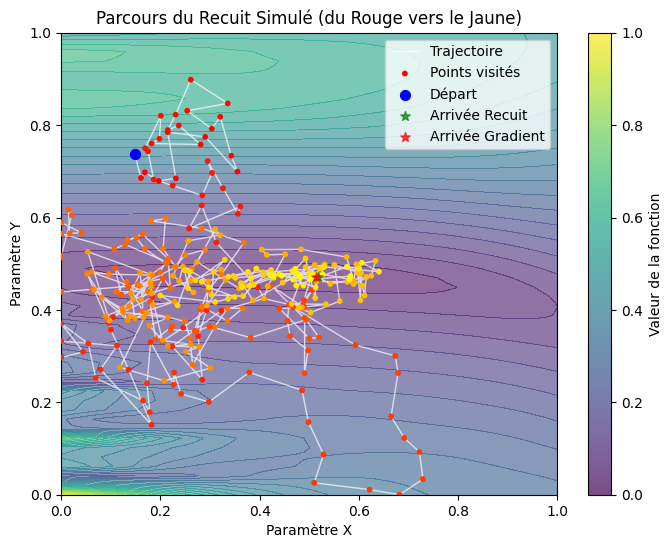

In [21]:
meilleure_position_Sinkhorn, meilleur_score_final,parcours = recuit_simule_hybride(f_Sinkhorn, [[0,1],[0,1]],cs_noise,temp_initiale=1)

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, Z_WD, levels=30, cmap='viridis', alpha=0.6)
plt.plot(parcours[:, 0], parcours[:, 1], color='white', linestyle='-', linewidth=1, alpha=0.7, label='Trajectoire')
plt.scatter(parcours[:, 0], parcours[:, 1], c=range(len(parcours)), cmap='autumn', s=10, zorder=3, label='Points visités')

plt.scatter(parcours[0, 0], parcours[0, 1], color='blue', s=50, marker='o', zorder=5, label='Départ')
plt.scatter(parcours[-2, 0], parcours[-2, 1], color='green', s=50, marker='*', zorder=5, label='Arrivée Recuit',alpha=.7)
plt.scatter(parcours[-1, 0], parcours[-1, 1], color='red', s=50, marker='*', zorder=5, label='Arrivée Gradient',alpha=.7)
plt.colorbar(label='Valeur de la fonction')
plt.title("Parcours du Recuit Simulé (du Rouge vers le Jaune)")
plt.xlabel("Paramètre X")
plt.ylabel("Paramètre Y")
plt.legend()
plt.show()

In [22]:
alpha_n,phi_n=meilleure_position_L2
alpha=10**(alpha_n*2-1)
phi=10**(phi_n-1.3)
cs_noise_under=cs_noise.copy()
cs_L2_under=multipeaks(times_norm,[0,20*seconds_in_day],alpha=alpha,R=220,Q=10000/1000/60,Phi=phi,L=20)

alpha_n,phi_n=meilleure_position_WD
alpha=10**(alpha_n*2-1)
phi=10**(phi_n-1.3)
    
cs_WD_under=multipeaks(times_norm,[0,20*seconds_in_day],alpha=alpha,R=220,Q=10000/1000/60,Phi=phi,L=20)

alpha_n,phi_n=meilleure_position_Sinkhorn
alpha=10**(alpha_n*2-1)
phi=10**(phi_n-1.3)
    
cs_Sinkhorn_under=multipeaks(times_norm,[0,20*seconds_in_day],alpha=alpha,R=220,Q=10000/1000/60,Phi=phi,L=20)

# Figure

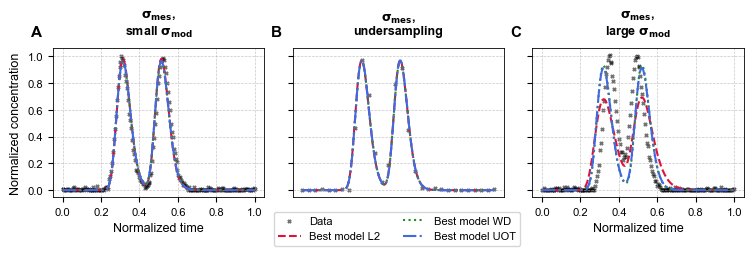

In [23]:
import numpy as np
import matplotlib.pyplot as plt

mm_to_inch = 1 / 25.4
fig_width_mm = 190.0   
fig_height_mm = 60.0 


plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'mathtext.fontset': 'dejavusans',
    'font.size': 8,             
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.linewidth': 0.6,      
    'figure.autolayout': False  
})


fig, axs = plt.subplots(1, 3, figsize=(fig_width_mm * mm_to_inch, fig_height_mm * mm_to_inch), 
                        sharey=True)

x_plot = times_norm / np.max(times_norm)
y_norm_factor = np.max(cs_noise_small)

axs[0].scatter(x_plot, cs_noise_small/y_norm_factor, c='black', s=5, alpha=0.55,marker='x',
               label=r'Data')

axs[0].plot(x_plot, cs_L2_small/y_norm_factor, c='crimson', linewidth=1.5, linestyle='--',
            label=r'Best model L2')

axs[0].plot(x_plot, cs_WD_small/y_norm_factor, c='forestgreen', linewidth=1.5, linestyle=':',
            label=r'Best model WD')

axs[0].plot(x_plot, cs_Sinkhorn_small/y_norm_factor, c='royalblue', linewidth=1.5, linestyle='-.',
            label=r'Best model UOT')


axs[1].scatter(times/np.max(times), cs_noise_under/y_norm_factor, c='black', s=5, alpha=0.55,marker='x',
               label=r'Data')

axs[1].plot(x_plot, cs_L2_under/y_norm_factor, c='crimson', linewidth=1.5, linestyle='--',
            label=r'Best model L2')

axs[1].plot(x_plot, cs_WD_under/y_norm_factor, c='forestgreen', linewidth=1.5, linestyle=':',
            label=r'Best model WD')

axs[1].plot(x_plot, cs_Sinkhorn_under/y_norm_factor, c='royalblue', linewidth=1.5, linestyle='-.',
            label=r'Best model UOT')

axs[2].scatter(x_plot, cs_noise_large/y_norm_factor, c='black', s=5, alpha=0.55,marker='x',
               label=r'Data')

axs[2].plot(x_plot, cs_L2_large/y_norm_factor, c='crimson', linewidth=1.5, linestyle='--',
            label=r'Best model L2')

axs[2].plot(x_plot, cs_WD_large/y_norm_factor, c='forestgreen', linewidth=1.5, linestyle=':',
            label=r'Best model WD')

axs[2].plot(x_plot, cs_Sinkhorn_large/y_norm_factor, c='royalblue', linewidth=1.5, linestyle='-.',
            label=r'Best model UOT')




panel_titles = [
    r"$\mathbf{\sigma_{mes}}$," + "\n" + r"small $\mathbf{\sigma_{mod}}$",
    r"$\mathbf{\sigma_{mes}}$," + "\n" + "undersampling", 
    r"$\mathbf{\sigma_{mes}}$," + "\n" + r"large $\mathbf{\sigma_{mod}}$"
]
panel_letters = ['A', 'B', 'C']
for i, ax in enumerate(axs):

    ax.set_xlabel('Normalized time')
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    ax.set_title(panel_titles[i], fontsize=9, fontweight='bold', pad=10)
    ax.text(-0.05, 1.06, panel_letters[i], transform=ax.transAxes, 
        fontsize=11, fontweight='bold', va='bottom', ha='right')

axs[0].set_ylabel('Normalized concentration')

handles, labels = axs[0].get_legend_handles_labels()
axs[1].set_xlabel('')
axs[1].set_xticks([])
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.525, -0.05), 
           ncol=2, frameon=True, edgecolor='0.8', fontsize=8)

plt.tight_layout(pad=.5, w_pad=.5)


plt.savefig('res/05_tracer_noise.pdf', format='pdf', bbox_inches='tight', dpi=600)
plt.show()

This code was run 1000 times in each set ups and the results are stored in the 'res' folder to produce the following figure


In [24]:
BEST_L2_1=np.load('res/best_L2_std1.npy')
BEST_WD_1=np.load('res/best_WD_std1.npy')
BEST_S_1=np.load('res/best_S_std1.npy')
BEST_L2_4=np.load('res/best_L2_std4.npy')
BEST_WD_4=np.load('res/best_WD_std4.npy')
BEST_S_4=np.load('res/best_S_std4.npy')
BEST_L2_under=np.load('res/best_L2_std_under.npy')
BEST_WD_under=np.load('res/best_WD_std_under.npy')
BEST_S_under=np.load('res/best_S_std_under.npy')

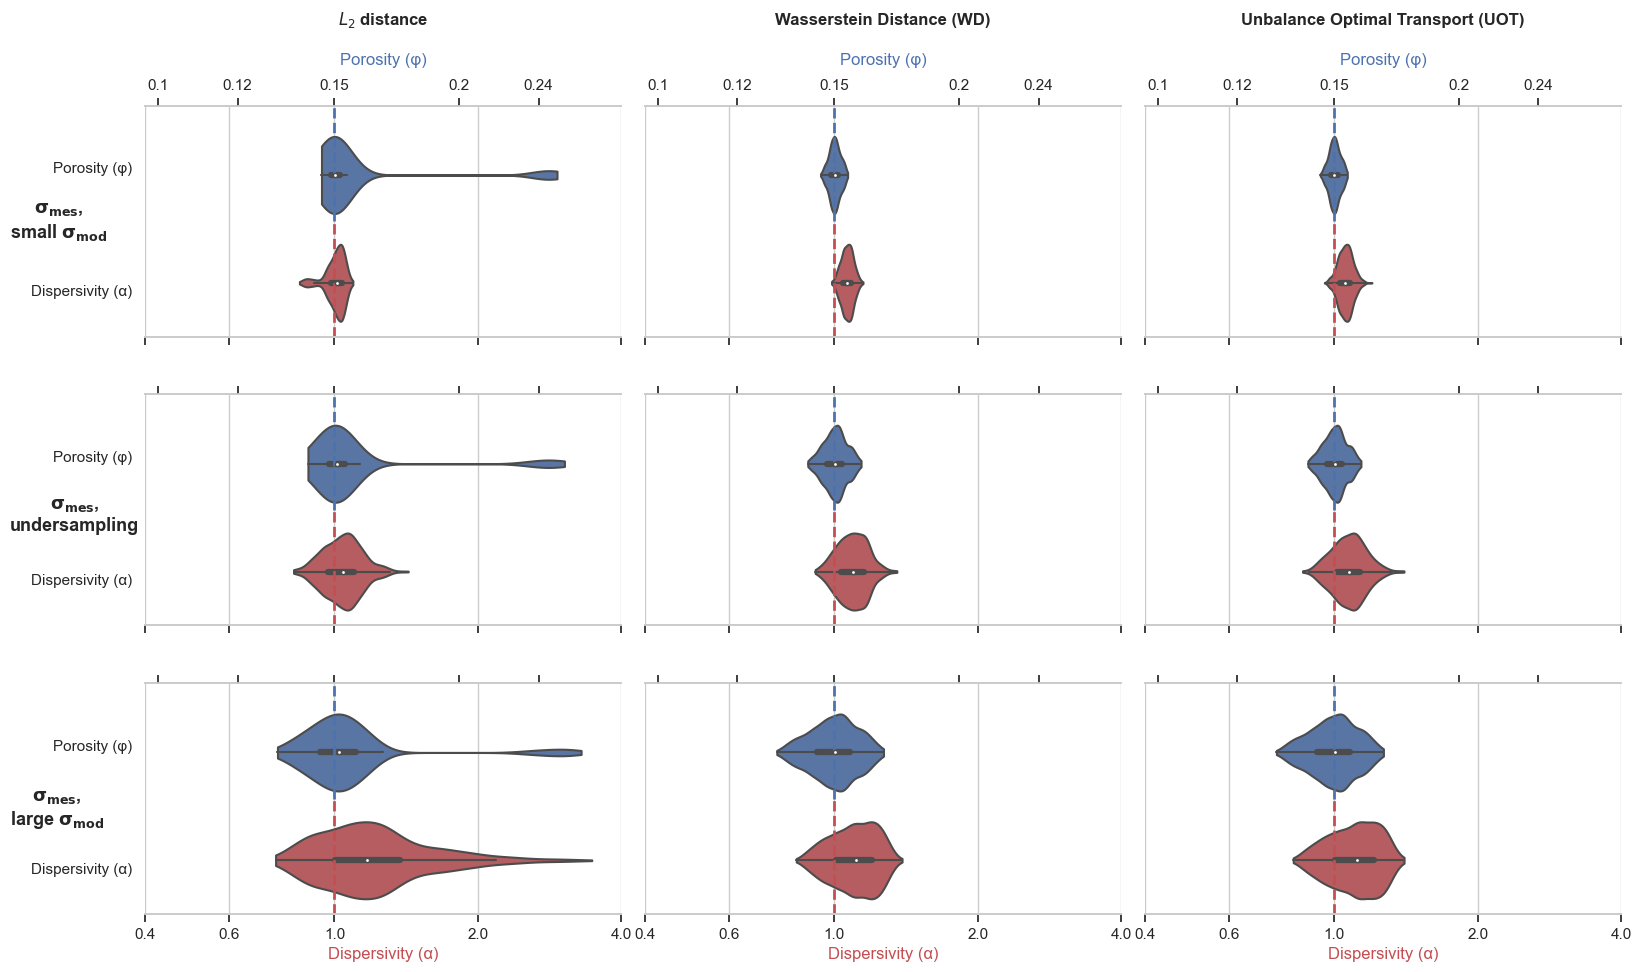

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

configurations = [
    {
        "datasets": {"L2": BEST_L2_1, "WD": BEST_WD_1, "S": BEST_S_1},
        "text": r"$\mathbf{\sigma_{mes}}$," + "\n" + r"small $\mathbf{\sigma_{mod}}$",
    },
    {
        "datasets": {"L2": BEST_L2_under, "WD": BEST_WD_under, "S": BEST_S_under},
        "text": r"$\mathbf{\sigma_{mes}}$," + "\n" + "undersampling",
    },
    {
        "datasets": {"L2": BEST_L2_4, "WD": BEST_WD_4, "S": BEST_S_4},
        "text": r"$\mathbf{\sigma_{mes}}$," + "\n" + r"large $\mathbf{\sigma_{mod}}$",
    },
]


fig, axes = plt.subplots(3, 3, figsize=(18, 10.5)) 
sns.set_theme(style="whitegrid", context="notebook")

facteur_echelle_phi = 0.5 / (1.3 + np.log10(0.15))

phi_ticks_physiques = [0.1, 0.12, 0.15, 0.2, 0.24]
phi_ticks_graphique = [
    (1.3 + np.log10(val)) * facteur_echelle_phi for val in phi_ticks_physiques
]

alpha_ticks_physiques = [0.4, 0.6, 1.0, 2.0, 4.0]
alpha_ticks_graphique = [
    (np.log10(val) + 1) / 2 for val in alpha_ticks_physiques
]

alpha_line = 0.5
phi_line = 0.5

limite_gauche = (np.log10(0.4) + 1) / 2
limite_droite = (np.log10(4.0) + 1) / 2
limite_bas, limite_haut = 4, -3.5

palette_params = {"Porosity (φ)": "#4C72B0", "Dispersivity (α)": "#C44E52"}
col_keys = ["L2", "WD", "S"]
titles = ["$L_2$ distance", "Wasserstein Distance (WD)", "Unbalance Optimal Transport (UOT)"]

for row_idx, config in enumerate(configurations):
    for col_idx, col_key in enumerate(col_keys):
        ax = axes[row_idx, col_idx]
        data_matrix = config["datasets"][col_key]

        df = pd.DataFrame(
            {
                "Valeurs": np.concatenate(
                    [data_matrix[:, 1] * facteur_echelle_phi, data_matrix[:, 0]]
                ),
                "Paramètre": ["Porosity (φ)"] * len(data_matrix)
                + ["Dispersivity (α)"] * len(data_matrix),
            }
        )

        sns.violinplot(
            data=df,
            x="Valeurs",
            y="Paramètre",
            ax=ax,
            hue="Paramètre",
            legend=False,
            palette=palette_params,
            width=5,
            density_norm="width",
            cut=0,
        )

        ax.axvline(phi_line, ymin=0.5, ymax=1.0, color="#4C72B0", linestyle="--", linewidth=2)
        ax.axvline(alpha_line, ymin=0.0, ymax=0.5, color="#C44E52", linestyle="--", linewidth=2)

        ax.set_xlim(limite_gauche, limite_droite)
        ax.set_ylim(limite_bas, limite_haut)
        ax.set_ylabel("")

        if col_idx == 0:
            ax.set_yticks([-1.5, 2.5])
            ax.set_yticklabels(["Porosity (φ)", "Dispersivity (α)"])
        else:
            ax.set_yticks([0, 1])
            ax.set_yticklabels([])

        ax.set_xticks(alpha_ticks_graphique)
        if row_idx == 2:  
            ax.set_xticklabels([str(v) for v in alpha_ticks_physiques])
            ax.set_xlabel("Dispersivity (α)", color="#C44E52")
        else:  
            ax.set_xticklabels([])
            ax.set_xlabel("")

        ax_top = ax.twiny()
        ax_top.set_xlim(ax.get_xlim())
        ax_top.set_xticks(phi_ticks_graphique)
        
        if row_idx == 0: 
            ax_top.set_xticklabels([str(v) for v in phi_ticks_physiques])
            ax_top.set_xlabel("Porosity (φ)", color="#4C72B0", labelpad=10)
            ax.set_title(titles[col_idx], weight="bold", pad=20)  
        else:  
            ax_top.set_xticklabels([])
            ax_top.set_xlabel("")
        
        ax_top.grid(False)

        if ax.get_legend() is not None:
            ax.get_legend().remove()

sns.despine(fig=fig, left=True, top=False)

plt.subplots_adjust(left=0.08, wspace=0.05, hspace=0.25)

for row_idx, config in enumerate(configurations):
    y_pos = 0.77 - (row_idx * 0.28)  
    fig.text(
        0.005, 
        y_pos, 
        config["text"], 
        va="center", 
        ha="left",
        ma='center',
        fontsize=13, 
        weight="semibold"
    )

plt.savefig('res/06_violinplot.png',dpi=300,bbox_inches='tight')
